<a href="https://colab.research.google.com/github/yasumorishima/mlb-data-analysis/blob/main/notebooks/sql/wbc_2023_sandoval_scouting_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WBC 2023: Patrick Sandoval Scouting Report (SQL Version)

Pre-game scouting analysis using **DuckDB SQL** for the 2023 World Baseball Classic semifinal.

(2023年WBC準決勝 日本対メキシコ戦前の**SQL版**スカウティング分析)

## SQL Skills Demonstrated:
- `GROUP BY` with aggregate functions (`COUNT`, `AVG`, `STDDEV`)
- `CASE WHEN` for conditional aggregation
- `ROUND` for formatting
- Multiple table comparisons
- `PIVOT`-style queries

In [1]:
!pip install pybaseball duckdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00


In [2]:
from pybaseball import statcast
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Acquisition (データ取得)

In [ ]:
# Fetch 2022 season Statcast data (pre-WBC analysis)
df = statcast(start_dt='2022-03-30', end_dt='2022-12-31')
print(f"Total records: {len(df):,}")

In [4]:
# DuckDB connection
con = duckdb.connect()

## 2. Pitch Type Distribution (球種分布)

Sandoval's pitcher ID: 663776

In [5]:
# Get unique pitch types for Sandoval
pitch_types = con.execute("""
    SELECT DISTINCT pitch_type
    FROM df
    WHERE pitcher = 663776
      AND pitch_type IS NOT NULL
    ORDER BY pitch_type
""").df()

print("Sandoval's Pitch Types:")
print(pitch_types)

Sandoval's Pitch Types:
  pitch_type
0         CH
1         CU
2         FF
3         SI
4         SL


## 3. Pitch Usage by Batter Handedness (打者左右別の球種使用率)

**Key Finding**: Against left-handed batters, Sandoval throws sliders 49.2% of the time.

In [6]:
# Pitch count by batter side using SQL with percentage calculation
pitch_usage = con.execute("""
    WITH sandoval_pitches AS (
        SELECT *
        FROM df
        WHERE pitcher = 663776
          AND pitch_type IS NOT NULL
    ),
    totals AS (
        SELECT
            stand,
            COUNT(*) as total_pitches
        FROM sandoval_pitches
        GROUP BY stand
    )
    SELECT
        sp.stand as batter_side,
        sp.pitch_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / t.total_pitches, 1) as percentage
    FROM sandoval_pitches sp
    JOIN totals t ON sp.stand = t.stand
    GROUP BY sp.stand, sp.pitch_type, t.total_pitches
    ORDER BY sp.stand, count DESC
""").df()

print("Pitch Usage by Batter Side:")
print(pitch_usage.to_string(index=False))

Pitch Usage by Batter Side:
batter_side pitch_type  count  percentage
          L         SL    237        49.2
          L         SI    148        30.7
          L         FF     55        11.4
          L         CU     23         4.8
          L         CH     19         3.9
          R         CH    585        29.6
          R         FF    503        25.5
          R         SL    479        24.3
          R         CU    204        10.3
          R         SI    203        10.3


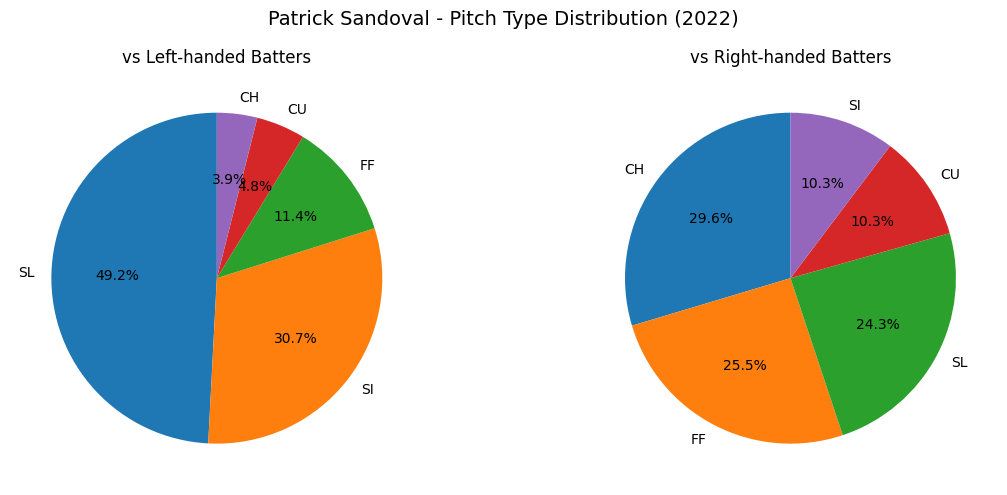

In [7]:
# Visualize pitch usage as pie charts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, side in enumerate(['L', 'R']):
    side_data = pitch_usage[pitch_usage['batter_side'] == side]
    axs[i].pie(side_data['count'], labels=side_data['pitch_type'],
               autopct='%.1f%%', startangle=90)
    axs[i].set_title(f"vs {'Left' if side == 'L' else 'Right'}-handed Batters")

plt.suptitle('Patrick Sandoval - Pitch Type Distribution (2022)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Velocity & Spin Rate Comparison (球速・回転数の比較)

Comparing Sandoval vs MLB average.

In [8]:
# Compare Sandoval vs MLB average using SQL
comparison = con.execute("""
    WITH mlb_avg AS (
        SELECT
            pitch_type,
            ROUND(AVG(release_speed), 2) as mlb_avg_speed,
            ROUND(STDDEV(release_speed), 2) as mlb_std_speed,
            ROUND(AVG(release_spin_rate), 0) as mlb_avg_spin,
            ROUND(STDDEV(release_spin_rate), 0) as mlb_std_spin
        FROM df
        WHERE pitch_type IS NOT NULL
        GROUP BY pitch_type
    ),
    sandoval AS (
        SELECT
            pitch_type,
            ROUND(AVG(release_speed), 2) as sandoval_avg_speed,
            ROUND(STDDEV(release_speed), 2) as sandoval_std_speed,
            ROUND(AVG(release_spin_rate), 0) as sandoval_avg_spin,
            ROUND(STDDEV(release_spin_rate), 0) as sandoval_std_spin
        FROM df
        WHERE pitcher = 663776
          AND pitch_type IS NOT NULL
        GROUP BY pitch_type
    )
    SELECT
        s.pitch_type,
        s.sandoval_avg_speed,
        m.mlb_avg_speed,
        ROUND(s.sandoval_avg_speed - m.mlb_avg_speed, 2) as speed_diff,
        s.sandoval_avg_spin,
        m.mlb_avg_spin,
        ROUND(s.sandoval_avg_spin - m.mlb_avg_spin, 0) as spin_diff
    FROM sandoval s
    JOIN mlb_avg m ON s.pitch_type = m.pitch_type
    ORDER BY s.pitch_type
""").df()

print("Sandoval vs MLB Average (Speed & Spin Rate):")
print(comparison.to_string(index=False))

Sandoval vs MLB Average (Speed & Spin Rate):
pitch_type  sandoval_avg_speed  mlb_avg_speed  speed_diff  sandoval_avg_spin  mlb_avg_spin  spin_diff
        CH               83.70          85.35       -1.65             1608.0        1752.0     -144.0
        CU               78.56          78.72       -0.16             2779.0        2530.0      249.0
        FF               93.06          93.94       -0.88             2038.0        2276.0     -238.0
        SI               93.43          93.36        0.07             1924.0        2141.0     -217.0
        SL               86.27          85.16        1.11             2551.0        2401.0      150.0


## 5. Batting Results Against Sandoval (対サンドバル被打撃結果)

In [9]:
# Batting results by batter side using SQL
batting_results = con.execute("""
    WITH sandoval_results AS (
        SELECT *
        FROM df
        WHERE pitcher = 663776
          AND events IS NOT NULL
          AND events NOT IN ('walk', 'hit_by_pitch', 'sac_fly', 'sac_bunt', 'catcher_interf')
    )
    SELECT
        stand as batter_side,
        COUNT(*) as at_bats,
        SUM(CASE WHEN events IN ('single', 'double', 'triple', 'home_run') THEN 1 ELSE 0 END) as hits,
        SUM(CASE WHEN events = 'home_run' THEN 1 ELSE 0 END) as home_runs,
        ROUND(SUM(CASE WHEN events IN ('single', 'double', 'triple', 'home_run') THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 3) as batting_avg
    FROM sandoval_results
    GROUP BY stand
    ORDER BY stand
""").df()

print("Batting Results vs Sandoval by Batter Side:")
print(batting_results.to_string(index=False))

Batting Results vs Sandoval by Batter Side:
batter_side  at_bats  hits  home_runs  batting_avg
          L      121  18.0        0.0        0.149
          R      460 124.0        9.0        0.270


## 6. Hit Distribution by Event Type (打球種別分布)

In [10]:
# Get hit location data for visualization
df_sandoval_hits = con.execute("""
    SELECT
        hc_x, hc_y, events, stand
    FROM df
    WHERE pitcher = 663776
      AND events IN ('single', 'double', 'triple', 'home_run')
      AND hc_x IS NOT NULL
      AND hc_y IS NOT NULL
""").df()

df_sandoval_outs = con.execute("""
    SELECT
        hc_x, hc_y, events, stand
    FROM df
    WHERE pitcher = 663776
      AND events NOT IN ('single', 'double', 'triple', 'home_run', 'walk', 'hit_by_pitch')
      AND hc_x IS NOT NULL
      AND hc_y IS NOT NULL
""").df()

print(f"Hits against Sandoval: {len(df_sandoval_hits)}")
print(f"Outs against Sandoval: {len(df_sandoval_outs)}")

Hits against Sandoval: 142
Outs against Sandoval: 290


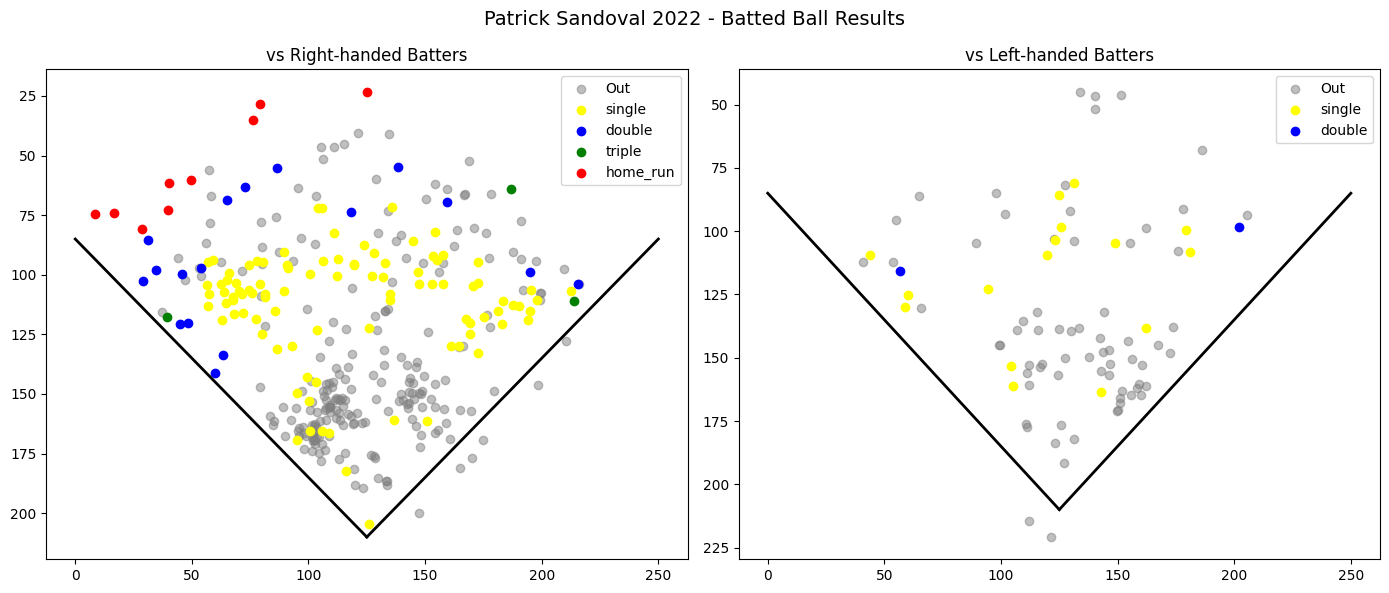

In [11]:
# Plot hit distribution by batter side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_hits(ax, df_hits, df_outs, title):
    # Outs in gray
    ax.scatter(df_outs['hc_x'], df_outs['hc_y'], color='gray', alpha=0.5, label='Out', zorder=1)

    # Hits by type
    colors = {'single': 'yellow', 'double': 'blue', 'triple': 'green', 'home_run': 'red'}
    for event, color in colors.items():
        event_data = df_hits[df_hits['events'] == event]
        if len(event_data) > 0:
            ax.scatter(event_data['hc_x'], event_data['hc_y'], color=color, label=event, zorder=2)

    # Foul lines
    ax.plot([125, 250], [210, 85], 'k-', lw=2)
    ax.plot([125, 0], [210, 85], 'k-', lw=2)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend(loc='upper right')

# Right-handed batters
plot_hits(ax1,
          df_sandoval_hits[df_sandoval_hits['stand'] == 'R'],
          df_sandoval_outs[df_sandoval_outs['stand'] == 'R'],
          'vs Right-handed Batters')

# Left-handed batters
plot_hits(ax2,
          df_sandoval_hits[df_sandoval_hits['stand'] == 'L'],
          df_sandoval_outs[df_sandoval_outs['stand'] == 'L'],
          'vs Left-handed Batters')

plt.suptitle('Patrick Sandoval 2022 - Batted Ball Results', fontsize=14)
plt.tight_layout()
plt.show()

## Key Scouting Insights

1. **vs Left-handed batters**: Sandoval throws sliders ~49% of the time
2. **Home Run vulnerability**: 0 HR allowed to left-handed batters in 2022
3. **Lower batting average**: Left-handed batters hit only .149 against him
4. **SQL Advantage**: Complex multi-table aggregations in single queries